# Feature Engineering for Real Estate Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
df = pd.read_csv('C:\\capstone_project_dscience\\real_estate_project\\dataset\\gurgaon_cleaned_v1.csv')

    as i have already did the feature engineering on the 'areaWithType' column so i am going to remove the 'areaWithType' column

In [4]:
df.drop(columns=['areaWithType'],inplace=True)

**additionalRoom**

    there are basically 5 types of rooms in this column
        1) servant room
        2) study room
        3) pooja room
        4) store room
        5) others

    so i am going to make 5 columns for each type and write 1 if present and 0 if not present

In [5]:
df['additionalRoom'].value_counts()

additionalRoom
Servant Room                                     708
Study Room                                       250
Others                                           230
Pooja Room                                       165
Store Room                                        99
Study Room,Servant Room                           98
Pooja Room,Servant Room                           80
Pooja Room,Study Room,Servant Room,Store Room     73
Servant Room,Others                               60
Pooja Room,Study Room,Servant Room                54
Pooja Room,Study Room,Servant Room,Others         51
Servant Room,Pooja Room                           38
Servant Room,Store Room                           31
Study Room,Others                                 30
Pooja Room,Study Room                             23
Pooja Room,Others                                 17
Pooja Room,Store Room                             15
Pooja Room,Store Room,Study Room,Servant Room     12
Servant Room,Study Room        

In [6]:
df['additionalRoom'] = df['additionalRoom'].str.lower()

In [7]:
new_cols = ['store room', 'servant room', 'puja room', 'study room', 'others']
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

    now i can remove the 'additionalRoom' column

In [8]:
df.drop(columns=['additionalRoom'], inplace=True)

**facing**


In [9]:
df['facing'].value_counts()

facing
East          651
North-East    642
North         406
West          253
South         235
North-West    196
South-East    173
South-West    158
Name: count, dtype: int64

    around 1093 values are missing from this column so i am going to fill them with 'East' direction because most of the people prefer this facing because of astrology

In [10]:
df.fillna({'facing':'Unknown'}, inplace=True).head()

,property_type,sector,society,price,price_per_sqft,area,super_built_up_area,built_up_area,carpet_area,bedRoom,bathroom,balcony,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,store room,servant room,puja room,study room,others
0,flat,sector 113,smartworld one dxp,2.00,11074.0,1806.03,NaN,1806.0,1350.0,3.0,3.0,3,12.0,North,undefined,"['Palam Vihar Vyapar kendra', 'Palam triangle'...",Best in class property available at sector 113...,"['1 Wardrobe', '1 Fan', '1 Exhaust Fan', '1 Ge...","['Swimming Pool', 'Salon', 'Restaurant', 'Spa'...","['Environment5 out of 5', 'Lifestyle4 out of 5...",0,1,0,0,0
1,house,sector 43,NaN,2.10,38251.0,549.01,NaN,549.0,NaN,10.0,10.0,3+,5.0,West,0 to 1 Year Old,"['Sector 42-43 metro station', 'Huda city cent...","Monthly rental income is rs1,40,000/- Best opt...","['10 Bed', '3 Fan', '10 Geyser', '2 Light', 'N...","['Terrace Garden', 'Gazebo', 'Fountain', 'Amph...","['Environment5 out of 5', 'Lifestyle5 out of 5...",0,1,0,0,0
2,house,sector 108,sobha city,10.50,14323.0,7330.87,NaN,7331.0,NaN,5.0,4.0,3+,1.0,East,undefined,"['Dwarka Sector 21', 'Dwarka Expressway', 'Vas...",Most luxurious property in the vicinity sobha ...,"['1 Water Purifier', '21 Fan', '1 Fridge', '1 ...","['Swimming Pool', 'Volley Ball Court', 'Aerobi...","['Environment4 out of 5', 'Lifestyle4.5 out of...",0,1,0,0,0
3,flat,sector 108,sobha city,3.95,16859.0,2342.96,NaN,2343.0,2300.0,4.0,5.0,3,25.0,West,undefined,"['Dwarka Sector 21', 'Dwarka Expressway', 'Vas...",This is sale property............................,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...","['Swimming Pool', 'Volley Ball Court', 'Aerobi...","['Environment4 out of 5', 'Safety4.5 out of 5'...",0,0,0,0,1
4,house,sector 43,NaN,4.50,39062.0,1152.01,NaN,1152.0,NaN,20.0,20.0,3+,4.0,East,1 to 5 Year Old,"['Huda city centre metro station', 'New Life C...",Best for investment purpose. 3l rupees monthly...,"['1 Water Purifier', '1 Fridge', '20 Fan', '1 ...","['Mini Theatre', 'Doctor on Call', 'Concierge ...","['Environment5 out of 5', 'Lifestyle5 out of 5...",0,1,0,0,0


    lets apply onehotencoding on this to make different columns for each direction

In [11]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
encoder = ohe.fit_transform(df['facing'].values.reshape(-1,1))

In [12]:
encoder.toarray()

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(3807, 9))

    onehotencoded datframe

In [13]:
encoder_df = pd.DataFrame(encoder.toarray(),columns=ohe.categories_[0])

In [14]:
encoder_df.columns

Index(['East', 'North', 'North-East', 'North-West', 'South', 'South-East',
       'South-West', 'Unknown', 'West'],
      dtype='str')

In [15]:
df = pd.concat([df, encoder_df], axis=1)

    now we can remove the 'facing' column

In [16]:
df.drop(columns=['facing'], inplace=True)

**agePossesion**

In [17]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old        1645
5 to 10 Year Old        566
0 to 1 Year Old         529
undefined               362
10+ Year Old            299
Under Construction       96
Within 6 months          73
Within 3 months          28
2023-12-01 00:00:00      23
By 2023                  22
By 2024                  19
2024-12-01 00:00:00      17
2024-03-01 00:00:00      14
2024-01-01 00:00:00      10
2024-06-01 00:00:00       8
2024-10-01 00:00:00       8
2025-12-01 00:00:00       7
2023-08-01 00:00:00       7
2024-08-01 00:00:00       6
2023-11-01 00:00:00       5
2024-11-01 00:00:00       4
2023-10-01 00:00:00       4
By 2025                   4
2023-09-01 00:00:00       4
2024-07-01 00:00:00       4
2024-02-01 00:00:00       3
2025-01-01 00:00:00       3
2024-05-01 00:00:00       3
2028-01-01 00:00:00       2
2026-08-01 00:00:00       2
By 2027                   2
2025-09-01 00:00:00       2
2026-12-01 00:00:00       2
2026-04-01 00:00:00       2
2027-07-01 00:00:00       2
2026-0

    so i am making 5 new columns out of this 'agePossession' column
    1) new property(0-1 year old)
    2) relatively new(1-5 year old)
    3) moderately old(5-10 year old)
    4) old(10+ year old)
    6) under construction(by 2025, may 2026)
    5) unknown 

In [18]:
def extract_age(age_str):
    if pd.isna(age_str):
        return np.nan
    if '0 to 1' in age_str or 'Within 6' in age_str or 'Within 1' in age_str:
        return 'new property'
    if '1 to 5' in age_str:
        return 'relatively new'
    if '5 to 10' in age_str:
        return 'moderately old'
    if '10+' in age_str:
        return 'old'
    if '-' in age_str or 'By' in age_str:
        return 'under construction'
    return 'unknown'

df['agePossession'] = df['agePossession'].apply(extract_age)
        

In [19]:
df['agePossession'].value_counts() 

agePossession
relatively new        1645
new property           602
moderately old         566
unknown                486
old                    299
under construction     208
Name: count, dtype: int64

    right now i didn't find anything useful from the column 'nearbyLocations', 'description' and 'rating'

In [20]:
df.drop(columns=['nearbyLocations', 'description', 'rating'],inplace=True)

**furnishDetails**
    
    here 2 approaches are possible, in the first approach i can make different categories in the furnishDetails. for eg: 'light', 'ac' etc.
    but there will be many columns by this way and it might be possible that not all the columns are that much useful. so i will do clustering here and try to find the best number of clusters.

In [21]:
df['furnishDetails'].value_counts()

furnishDetails
[]                                                                                                                                                                                                                                                                       440
['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']     217
['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']      72
['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fri

In [22]:
df['furnishDetails'][0].replace('[','').replace(']','').replace("'",'').split(', ')


['1 Wardrobe',
 '1 Fan',
 '1 Exhaust Fan',
 '1 Geyser',
 '1 Light',
 '1 Modular Kitchen',
 '1 AC',
 '1 Chimney',
 'No Bed',
 'No Curtains',
 'No Dining Table',
 'No Microwave',
 'No Fridge',
 'No Sofa',
 'No Stove',
 'No TV',
 'No Washing Machine',
 'No Water Purifier']

    first i will find out all the different items present in the furnishDetails column

In [23]:
import re

all_furnishings = []
for item in df['furnishDetails'].dropna():
    furnishing = item.replace('[','').replace(']','').replace("'",'').split(', ')
    all_furnishings.extend(furnishing)

unique_furnishings = list(set(all_furnishings))

columns_to_include = [re.sub(r'No |\d+', '', f).strip() for f in unique_furnishings]
columns_to_include = sorted(list(set([col for col in columns_to_include if col])))



In [24]:
def get_furnishing_number(details, item):
    if not isinstance(details, str) or not isinstance(item, str) or not item.strip():
        return 0

    item = item.strip()
    text = details.replace('[', '').replace(']', '').replace("'", '')

    # If "No <item>" appears, count is 0
    if re.search(rf"\bNo\s+{re.escape(item)}\b", text, flags=re.IGNORECASE):
        return 0

    # Extract number before the item (e.g., "12 Light" -> 12)
    match = re.search(rf"\b(\d+)\s+{re.escape(item)}\b", text, flags=re.IGNORECASE)
    return int(match.group(1)) if match else 0

    now i will make a dataframe which stores every items count

In [25]:
item_df = pd.DataFrame()
for item in columns_to_include:
    item_df[item] = df['furnishDetails'].apply(lambda x: get_furnishing_number(x, item))
item_df.head()

,AC,Bed,Chimney,Curtains,Dining Table,Exhaust Fan,Fan,Fridge,Geyser,Light,Microwave,Modular Kitchen,Sofa,Stove,TV,Wardrobe,Washing Machine,Water Purifier
0,1,0,1,0,0,1,1,0,1,1,0,1,0,0,0,1,0,0
1,0,10,0,0,0,0,3,0,10,2,0,0,0,0,0,0,0,0
2,0,21,1,1,1,1,21,1,21,21,1,1,1,1,0,21,1,1
3,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
4,0,20,0,1,1,1,20,1,20,0,1,0,1,1,0,20,1,1


    now lets apply clustering

In [26]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
stdscaler = StandardScaler()

scaled_data = stdscaler.fit_transform(item_df)

inertia_item = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(scaled_data)
    inertia_item.append(kmeans.inertia_)


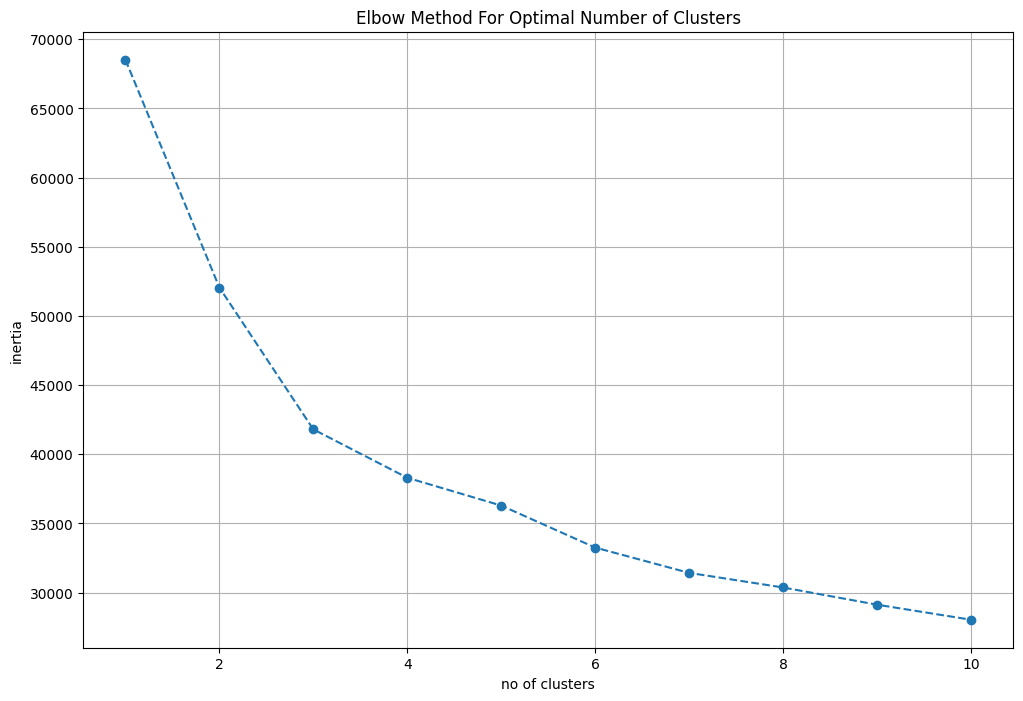

In [27]:
plt.figure(figsize=(12,8))
plt.plot(range(1,11),inertia_item,marker='o',linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters')
plt.xlabel('no of clusters')
plt.ylabel('inertia')
plt.grid(True)
plt.show()

In [28]:
sil_score = []
from sklearn.metrics import silhouette_score
for i in range(2,11):
    kmeans = KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(scaled_data)
    sil_score.append(silhouette_score(item_df,kmeans.labels_))

sil_score

[0.5626487733411075,
 0.4816855184159848,
 0.44615749690021017,
 0.4221104655626301,
 0.4209365221760409,
 0.41669342118827596,
 0.2740044112382489,
 0.2732296754341015,
 0.32299537643736626]

Text(0, 0.5, 'silhouette score')

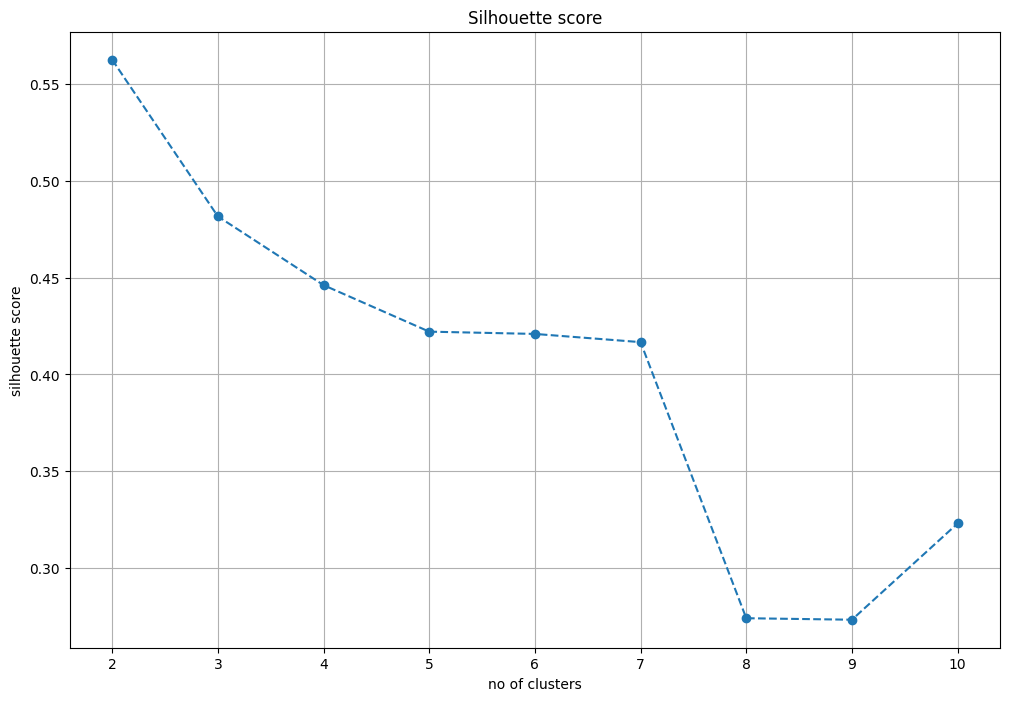

In [29]:
plt.figure(figsize=(12,8))
plt.plot(range(2,11),sil_score,linestyle='--',marker='o')
plt.grid(True)
plt.title('Silhouette score')
plt.xlabel('no of clusters')
plt.ylabel('silhouette score')


    even though from kmeans, if k = 2 then the silhouette score is the highest , but k = 3 also has a good silhouette score.so i am going to make 3 different categories in this column
    1) furnished
    2) semifurnished
    3) unfurnished

In [30]:
kmeans = KMeans(n_clusters=3,random_state=42)
kmeans.fit(scaled_data)

cluster_assignment = kmeans.predict(scaled_data)
df['furnish_type'] = cluster_assignment
df[['furnishDetails','furnish_type']].sample(20)

,furnishDetails,furnish_type
2868,"['1 Modular Kitchen', 'No AC', 'No Bed', 'No C...",1
687,"['12 Fan', '9 Geyser', '17 Light', 'No AC', 'N...",2
2562,[],1
3108,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",1
598,"['5 Fan', '1 Exhaust Fan', '6 Geyser', '1 Stov...",2
2060,"['3 Wardrobe', '1 Modular Kitchen', '1 Chimney...",1
2908,"['2 Wardrobe', '3 Fan', '1 Geyser', '5 Light',...",1
3236,NaN,1
176,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'N...",1
333,NaN,1


    2 -> furnished
    1 -> unfurnished
    0 -> semifurnished

 **features**

In [31]:
df['features'].value_counts()

features
['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              290
['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for ser

In [32]:
df['features'][0].replace('[','').replace(']','').replace("'",'').split(', ')

['Swimming Pool',
 'Salon',
 'Restaurant',
 'Spa',
 'Cafeteria',
 'Sun Deck',
 '24x7 Security',
 'Club House',
 'Gated Community']

In [33]:
luxury_count = []
for luxury in df['features'].dropna():
    items = luxury.replace('[','').replace(']','').replace("'",'').split(', ')
    luxury_count.extend(items)

unique_luxury = list(set(luxury_count))
unique_luxury

['Water Storage',
 'Theatre',
 'Gated Community',
 'Multipurpose Court',
 'Card Room',
 'Internal Street Lights',
 'Club house / Community Center',
 'Automated Car Wash',
 'Multipurpose Hall',
 'Solar Lighting',
 'High Speed Elevators',
 'Fountain',
 'Gazebo',
 'Bank Attached Property',
 'ATM',
 'Library',
 'Feng Shui / Vaastu Compliant',
 'Garbage Disposal',
 'Lift(s)',
 'Entrance Lobby',
 'Water softening plant',
 'Jacuzzi',
 'Sun Deck',
 'Water purifier',
 'School',
 'Security Cabin',
 'CCTV Camera Security',
 'Wi-Fi Connectivity',
 'Security / Fire Alarm',
 'Volley Ball Court',
 'Separate entry for servant room',
 'No open drainage around',
 'Intercom Facility',
 'Waste Disposal',
 'Indoor Games',
 'Private Garden / Terrace',
 'Golf Course',
 'Barbecue',
 'Basketball Court',
 'Car wash area',
 'Manicured Garden',
 'RO System',
 'Acupressure Park',
 'Lawn Tennis Court',
 'Cigar Lounge',
 'Security Personnel',
 'Bar/Chill-Out Lounge',
 'Table Tennis',
 'Power Back up Lift',
 '24/7 Po

    1)lets give the luxury score to each value according to their luxury
    2) calculate the total luxury score in each row in 'features' column

In [34]:
luxury_scores = {
"Pool Table": 45,
"Rain Water Harvesting": 30,
"Food Court": 60,
"Clinic": 40,
"Bus Shelter": 10,
"Multipurpose Hall": 50,
"Theater Home": 80,
"Centrally Air Conditioned": 85,
"Fountain": 55,
"Automated Car Wash": 65,
"Recently Renovated": 40,
"Infinity Pool": 92,
"Bank Attached Property": 25,
"Card Room": 45,
"Jacuzzi": 88,
"Conference room": 50,
"Piped-gas": 35,
"ATM": 20,
"Park": 40,
"Car Parking": 30,
"Steam Room": 80,
"Internet/wi-fi connectivity": 35,
"School": 45,
"Water softening plant": 35,
"Water Softener Plant": 35,
"Solar Lighting": 40,
"Spacious Interiors": 70,
"Reflexology Park": 65,
"Vastu Compliant": 30,
"Power Back-up": 40,
"Entrance Lobby": 50,
"Concierge Service": 90,
"Library": 55,
"Spa": 90,
"Landscape Garden": 60,
"Solar Water Heating": 35,
"Cafeteria": 50,
"Bowling Alley": 85,
"Acupressure Park": 60,
"Banquet Hall": 70,
"Indoor Games": 50,
"Wi-Fi Connectivity": 35,
"Lawn Tennis Court": 85,
"Manicured Garden": 70,
"Sewage Treatment Plant": 25,
"Party Lawn": 65,
"Table Tennis": 45,
"Security / Fire Alarm": 30,
"Foosball": 40,
"Cricket Pitch": 65,
"Flower Garden": 50,
"Earthquake Resistant": 45,
"24x7 Security": 35,
"Natural Pond": 60,
"Water Storage": 20,
"RO System": 30,
"Intercom Facility": 35,
"False Ceiling Lighting": 55,
"Lift(s)": 35,
"Bar/Chill-Out Lounge": 80,
"Business Lounge": 75,
"Fitness Centre / GYM": 75,
"Football": 60,
"Medical Centre": 45,
"Airy Rooms": 55,
"Laundry": 30,
"Grocery Shop": 35,
"Visitor Parking": 35,
"Yoga/Meditation Area": 65,
"Internal Street Lights": 25,
"Low Density Society": 85,
"24/7 Water Supply": 25,
"Golf Course": 100,
"Cigar Lounge": 90,
"Salon": 60,
"Changing Area": 30,
"TopFacilities": 50,
"Separate entry for servant room": 70,
"Security Personnel": 35,
"Maintenance Staff": 30,
"Sun Deck": 70,
"Squash Court": 85,
"Billiards": 55,
"Air Hockey": 45,
"Natural Light": 50,
"Video Door Security": 60,
"Mini Theatre": 85,
"Doctor on Call": 40,
"Basketball Court": 70,
"Community Hall": 50,
"Reading Lounge": 60,
"Waste Disposal": 20,
"Restaurant": 70,
"Terrace Garden": 75,
"Water purifier": 25,
"Waiting Lounge": 40,
"Aerobics Centre": 70,
"Beach Volley Ball Court": 75,
"Creche/Day care": 55,
"High Ceiling Height": 80,
"Lounge": 65,
"Toddler Pool": 75,
"Security Cabin": 25,
"Gated Community": 65,
"Swimming Pool": 90,
"Shopping Centre": 75,
"Power Back up Lift": 40,
"Childrens Play Area": 55,
"Fire Fighting Systems": 30,
"Club House": 85,
"24/7 Power Backup": 45,
"Barbecue": 65,
"Feng Shui / Vaastu Compliant": 30,
"Badminton Court": 75,
"Car wash area": 45,
"Private Garden / Terrace": 85,
"Gazebo": 65,
"Valet Parking": 90,
"No open drainage around": 20,
"Theatre": 75,
"Visitors Parking": 35,
"Senior Citizen Sitout": 45,
"High Speed Elevators": 65,
"Jogging Track": 65,
"Property Staff": 35,
"Garbage Disposal": 20,
"Club house / Community Center": 85,
"Gymnasium": 75,
"Piped Gas": 35,
"Sauna": 85,
"CCTV Camera Security": 45,
"Amphitheatre": 80,
"Milk Booth": 15,
"Temple": 40,
"Volley Ball Court": 65,
"Multipurpose Court": 70,
"Pergola": 65,
"Skating Rink": 80
}


def luxury_index(amenities):
    if pd.isna(amenities): return amenities
    return sum(luxury_scores.get(a, 1) for a in amenities)

df['luxury_score'] = df["features"].apply(luxury_index)

    now there is no need for 'features' column. so lets remove it

In [35]:
df.drop(columns=['features'],inplace=True)

    also delete the 'furnishDetails' column

In [36]:
df.drop(columns=['furnishDetails'],inplace=True)

In [37]:
df.to_csv('cleaned_gurgaon_v2.csv', index=False)